# Test-Set Model Evaluation

Evaluate the selected meta-models on the held-out period from `2022-01-01` onward. The final deliverable remains `deliverables/final_predictions.csv`, while this notebook shows diagnostics, metrics, and plots for each selected model.

In [1]:
from pathlib import Path
import os
import sys
import warnings

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "05_model_evaluation":
    PROJECT_ROOT = PROJECT_ROOT.parent

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")
warnings.filterwarnings(
    "ignore",
    message="Pandas requires version '2.10.2' or newer of 'numexpr'.*",
    category=UserWarning,
)

sys.path.insert(0, str(PROJECT_ROOT / "05_model_evaluation"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

import evaluate_selected_models as ev

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

CONFIG_PATH = PROJECT_ROOT / "results" / "selected_model_run_configs.csv"
DELIVERABLE_PATH = PROJECT_ROOT / "deliverables" / "final_predictions.csv"
OUTPUT_DIR = PROJECT_ROOT / "05_model_evaluation" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_PATH, DELIVERABLE_PATH, OUTPUT_DIR

(PosixPath('/Users/faisal/Desktop/systematic-strategies-with-machine-learning-Cw/results/selected_model_run_configs.csv'),
 PosixPath('/Users/faisal/Desktop/systematic-strategies-with-machine-learning-Cw/deliverables/final_predictions.csv'),
 PosixPath('/Users/faisal/Desktop/systematic-strategies-with-machine-learning-Cw/05_model_evaluation/outputs'))

## Selected Models

These are the configurations selected after model comparison and feature-importance selection. The same config CSV drives the deliverable-generation script.

In [2]:
configs = pd.read_csv(CONFIG_PATH)
selected_cols = [
    "ticker", "model_type", "model_name", "tb_config_name", "feature_method",
    "selection_rule", "mean_auc", "median_path_trade_sharpe", "train_rows",
    "processed_feature_count", "test_start_date",
]
display(configs[selected_cols])

,ticker,model_type,model_name,tb_config_name,feature_method,selection_rule,mean_auc,median_path_trade_sharpe,train_rows,processed_feature_count,test_start_date
0,cl1s,random_forest,rf_medium_depth,parkinson_10d_tp2_sl2,corr_cluster,top3_mean_auc_then_highest_median_path_trade_s...,0.635559,0.422354,333,70,2022-01-01
1,ho1s,logistic_regression,l2_C0.1,garman_klass_10d_tp2_sl2,pca,top3_mean_auc_then_highest_median_path_trade_s...,0.736165,0.631422,61,17,2022-01-01
2,ng1s,logistic_regression,l1_C1,garman_klass_10d_tp2_sl2,corr_cluster,top3_mean_auc_then_highest_median_path_trade_s...,0.619671,0.328293,68,68,2022-01-01
3,rb1s,logistic_regression,l2_C0.1,garman_klass_10d_tp2_sl2,pca,top3_mean_auc_then_highest_median_path_trade_s...,0.551840,0.050307,504,26,2022-01-01


**Interpretation**

The selected-model set contains one final meta-model per instrument. `cl1s` uses a random forest with correlation-clustered features, while `ho1s`, `ng1s`, and `rb1s` use logistic regression variants. This matters when reading the plots: the random forest probabilities are ensemble vote-style probabilities, while the logistic models produce smoother probability scores from standardized transformed features.

## Score The 2022+ Test Set

For each selected model, refit on the pre-2022 training rows and score the test events from `2022-01-01` onward. `prediction` is the positive-class probability, matching the final deliverable.

In [3]:
detailed_tables = []
for config in configs.itertuples(index=False):
    config_series = pd.Series(config._asdict())
    detailed = ev.fit_predict_detailed_config(config_series)
    detailed_tables.append(detailed)
    print(
        f"{config_series['ticker']}: {len(detailed)} test predictions "
        f"from {detailed['date'].min()} to {detailed['date'].max()}"
    )

detailed_predictions = (
    pd.concat(detailed_tables, ignore_index=True)
    .sort_values(["date", "instrument"])
    .reset_index(drop=True)
)

detailed_path = OUTPUT_DIR / "test_set_detailed_predictions.csv"
detailed_predictions.to_csv(detailed_path, index=False)

# Keep the final deliverable synchronized with this notebook run.
deliverable = detailed_predictions[["date", "instrument", "prediction"]].copy()
deliverable.to_csv(DELIVERABLE_PATH, index=False)

print(f"Detailed predictions: {detailed_path}")
print(f"Final deliverable: {DELIVERABLE_PATH}")
display(detailed_predictions.head())

cl1s: 78 test predictions from 2022-01-03 to 2022-06-15
ho1s: 2 test predictions from 2022-05-31 to 2022-06-02


ng1s: 52 test predictions from 2022-01-13 to 2022-06-08
rb1s: 114 test predictions from 2022-01-03 to 2022-06-15
Detailed predictions: /Users/faisal/Desktop/systematic-strategies-with-machine-learning-Cw/05_model_evaluation/outputs/test_set_detailed_predictions.csv
Final deliverable: /Users/faisal/Desktop/systematic-strategies-with-machine-learning-Cw/deliverables/final_predictions.csv


,date,instrument,prediction,predicted_label,model_type,model_name,tb_config_name,feature_method,y_true,primary_signal,signed_touch_return
0,2022-01-03,cl1s,0.957689,1,random_forest,rf_medium_depth,parkinson_10d_tp2_sl2,corr_cluster,1,1,0.044427
1,2022-01-03,rb1s,0.630837,1,logistic_regression,l2_C0.1,garman_klass_10d_tp2_sl2,pca,1,1,0.044715
2,2022-01-04,cl1s,0.951089,1,random_forest,rf_medium_depth,parkinson_10d_tp2_sl2,corr_cluster,1,1,0.054942
3,2022-01-04,rb1s,0.582021,1,logistic_regression,l2_C0.1,garman_klass_10d_tp2_sl2,pca,1,1,0.050301
4,2022-01-05,cl1s,0.945801,1,random_forest,rf_medium_depth,parkinson_10d_tp2_sl2,corr_cluster,1,1,0.043288


**Interpretation**

The evaluation rebuilds each selected model from `selected_model_run_configs.csv`, refits it only on rows before `2022-01-01`, and scores the held-out 2022+ labelled events. The notebook also refreshes `deliverables/final_predictions.csv`, but the detailed evaluation file keeps extra fields such as `y_true`, `predicted_label`, model metadata, and signed event returns for diagnostics.

## Test Metrics

Metrics use a `0.5` probability threshold for hard-label statistics. AUC, average precision, log loss, and calibration-style metrics use the raw probabilities where possible.

In [4]:
def safe_binary_metric(func, y_true, y_score, default=np.nan):
    try:
        if pd.Series(y_true).nunique() < 2:
            return default
        return func(y_true, y_score)
    except ValueError:
        return default


def metric_row(group, instrument=None):
    y_true = group["y_true"].astype(int).to_numpy()
    y_proba = group["prediction"].astype(float).to_numpy()
    y_pred = (y_proba >= 0.5).astype(int)
    positives = int(y_true.sum())
    negatives = int(len(y_true) - positives)
    row = {
        "instrument": instrument if instrument is not None else group["instrument"].iloc[0],
        "model_type": group["model_type"].iloc[0],
        "model_name": group["model_name"].iloc[0],
        "tb_config_name": group["tb_config_name"].iloc[0],
        "feature_method": group["feature_method"].iloc[0],
        "n_test": len(group),
        "positive_rate": positives / len(group),
        "mean_prediction": y_proba.mean(),
        "predicted_positive_rate": y_pred.mean(),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else np.nan,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": safe_binary_metric(roc_auc_score, y_true, y_proba),
        "average_precision": safe_binary_metric(average_precision_score, y_true, y_proba),
        "brier_score": brier_score_loss(y_true, y_proba),
        "log_loss": log_loss(y_true, y_proba, labels=[0, 1]),
        "n_positive": positives,
        "n_negative": negatives,
    }
    return pd.Series(row)

metrics = pd.DataFrame(
    [metric_row(group, instrument=instrument) for instrument, group in detailed_predictions.groupby("instrument", sort=True)]
)

overall_metrics = metric_row(detailed_predictions, instrument="overall").to_frame().T
metrics_with_overall = pd.concat([metrics, overall_metrics], ignore_index=True)

metrics_path = OUTPUT_DIR / "test_set_metrics.csv"
metrics_with_overall.to_csv(metrics_path, index=False)

metric_display_cols = [
    "instrument", "n_test", "positive_rate", "mean_prediction", "predicted_positive_rate",
    "accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc",
    "average_precision", "brier_score", "log_loss",
]
display(metrics_with_overall[metric_display_cols].round(4))
print(f"Saved metrics: {metrics_path}")

,instrument,n_test,positive_rate,mean_prediction,predicted_positive_rate,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier_score,log_loss
0,cl1s,78,0.807692,0.760076,0.987179,0.794872,0.492063,0.805195,0.984127,0.885714,0.678307,0.920751,0.149542,0.454415
1,ho1s,2,0.0,0.138044,0.0,1.0,NaN,0.0,0.0,0.0,NaN,NaN,0.02153,0.150219
2,ng1s,52,0.384615,0.287281,0.269231,0.538462,0.484375,0.357143,0.25,0.294118,0.567187,0.460311,0.404014,2.066431
3,rb1s,114,0.692982,0.456053,0.438596,0.605263,0.651537,0.84,0.531646,0.651163,0.690778,0.853036,0.25214,0.71185
4,overall,246,0.658537,0.51419,0.573171,0.654472,0.645944,0.77305,0.67284,0.719472,0.674089,0.751919,0.249837,0.911993


Saved metrics: /Users/faisal/Desktop/systematic-strategies-with-machine-learning-Cw/05_model_evaluation/outputs/test_set_metrics.csv


**Interpretation**

Overall test accuracy is about `0.6545`, with overall ROC AUC around `0.6741`, so the selected meta-models show useful ranking power on the combined 2022+ test set. `cl1s` has the strongest hard-label F1 because it predicts nearly all true positives, but its balanced accuracy is close to random because it struggles with the minority class. `rb1s` has the strongest balanced accuracy among the larger test sets, while `ng1s` is weaker across accuracy, F1, and AUC. `ho1s` only has two test events and a single observed class, so its perfect accuracy is not very informative and AUC-style metrics are undefined.

## Accuracy, F1, And AUC By Instrument

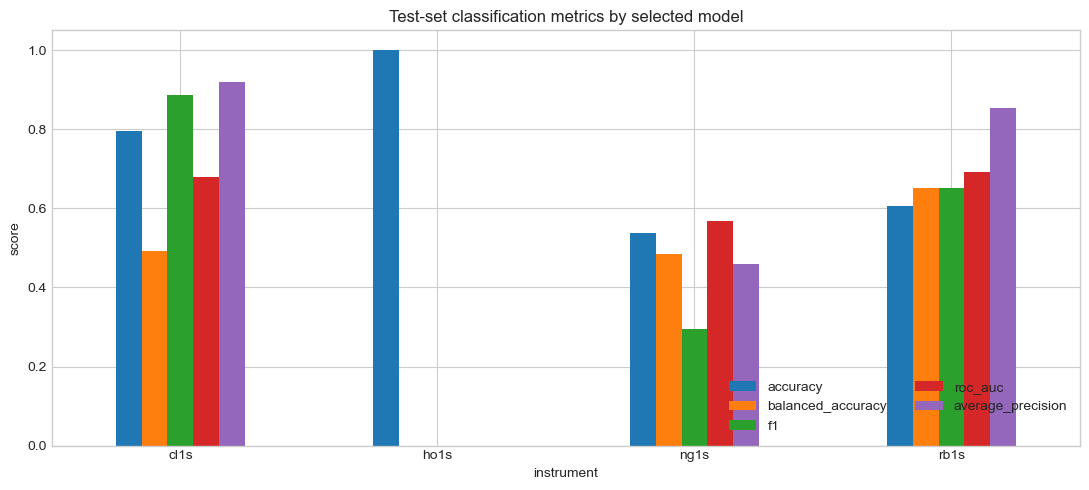

In [5]:
plot_metrics = metrics.set_index("instrument")[["accuracy", "balanced_accuracy", "f1", "roc_auc", "average_precision"]]
fig, ax = plt.subplots(figsize=(11, 5))
plot_metrics.plot(kind="bar", ax=ax)
ax.set_title("Test-set classification metrics by selected model")
ax.set_ylabel("score")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right", ncol=2)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation**

The metric bars make the trade-off clearer: `cl1s` looks good on accuracy and F1 because the test set is heavily positive, but balanced accuracy is much lower. `rb1s` is more balanced, with a better mix of recall and class separation. `ng1s` underperforms relative to the others, suggesting either the selected model is not generalising well or the 2022+ gas regime is materially different from the training period.

## Confusion Matrices

Hard labels are generated with `prediction >= 0.5`.

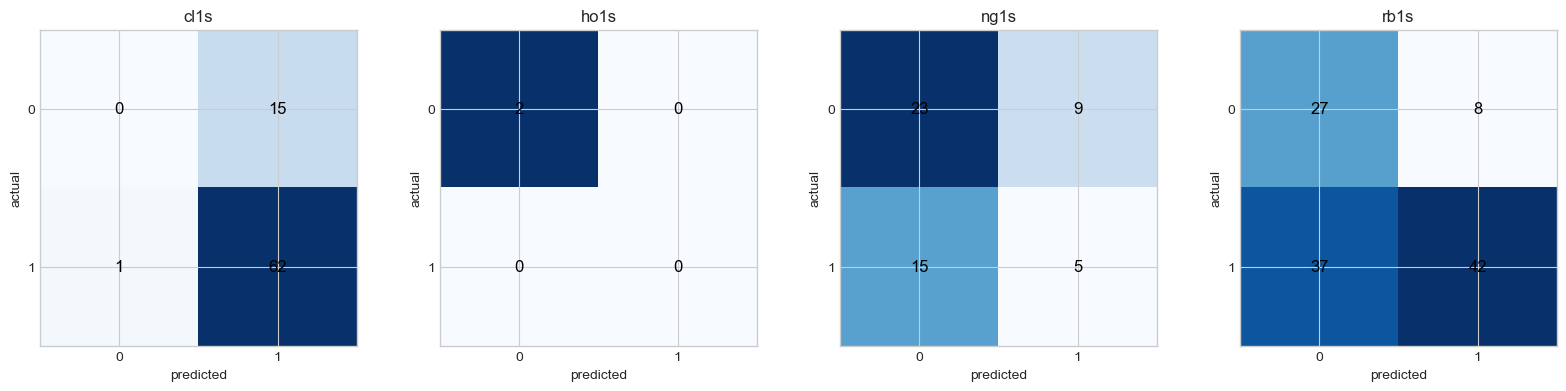

In [6]:
instruments = metrics["instrument"].tolist()
fig, axes = plt.subplots(1, len(instruments), figsize=(4 * len(instruments), 3.8), constrained_layout=True)
if len(instruments) == 1:
    axes = [axes]

for ax, instrument in zip(axes, instruments):
    group = detailed_predictions[detailed_predictions["instrument"] == instrument]
    y_true = group["y_true"].astype(int).to_numpy()
    y_pred = (group["prediction"].astype(float).to_numpy() >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{instrument}")
    ax.set_xlabel("predicted")
    ax.set_ylabel("actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    for (i, j), value in np.ndenumerate(cm):
        ax.text(j, i, str(value), ha="center", va="center", color="black", fontsize=12)

plt.show()

**Interpretation**

The confusion matrices show where each model makes mistakes at the default `0.5` threshold. `cl1s` takes almost every event, which captures most positives but leaves little protection against false positives. `rb1s` rejects more events and therefore has a more meaningful trade-off between false positives and false negatives. `ho1s` has too few events to judge from a confusion matrix, so it should not drive conclusions.

## Probability Distributions

These plots show whether the model assigns higher probabilities to true positives than true negatives.

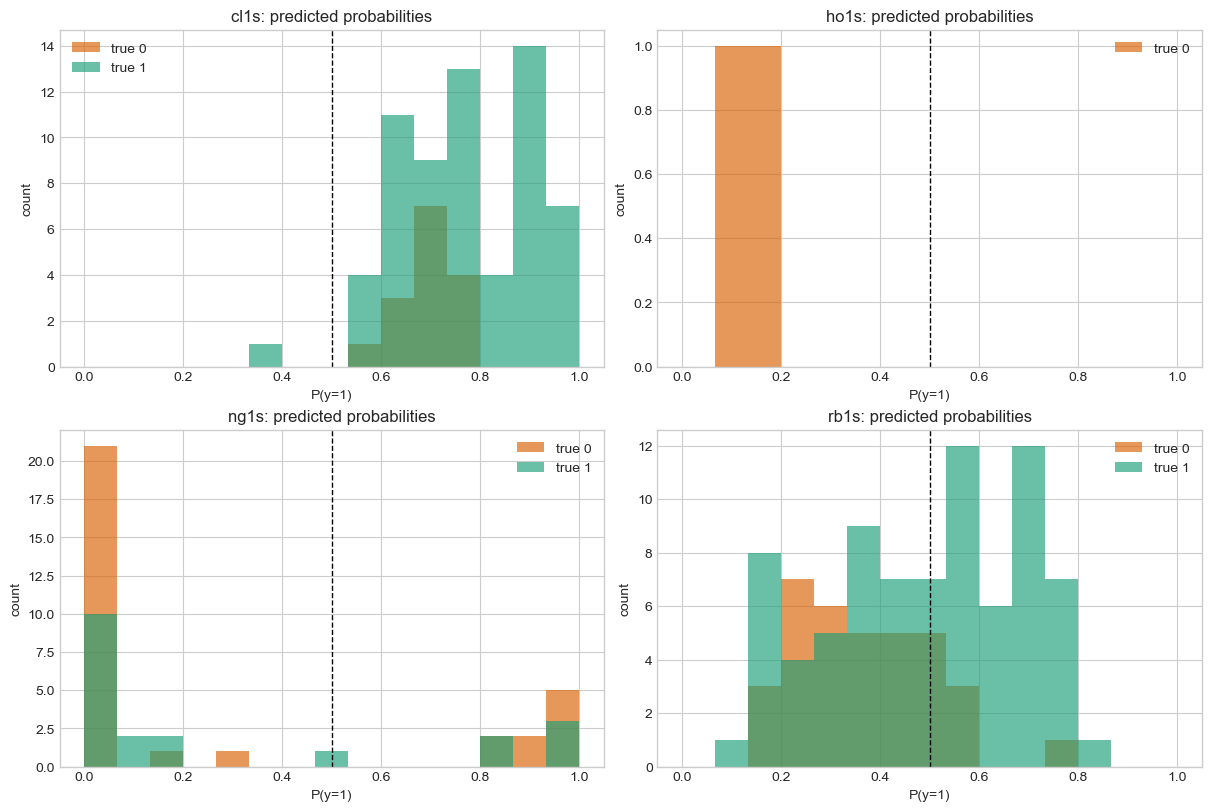

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes = axes.ravel()

for ax, instrument in zip(axes, instruments):
    group = detailed_predictions[detailed_predictions["instrument"] == instrument]
    for y_value, label, color in [(0, "true 0", "#d95f02"), (1, "true 1", "#1b9e77")]:
        vals = group.loc[group["y_true"] == y_value, "prediction"].astype(float)
        if len(vals):
            ax.hist(vals, bins=np.linspace(0, 1, 16), alpha=0.65, label=label, color=color)
    ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{instrument}: predicted probabilities")
    ax.set_xlabel("P(y=1)")
    ax.set_ylabel("count")
    ax.legend()

plt.show()

**Interpretation**

The probability histograms show score separation. A useful meta-model should push true positives toward higher probabilities and true negatives toward lower probabilities. `rb1s` shows a healthier spread than the hard-label metrics alone imply. `ng1s` has more overlap between true classes, which explains its weaker F1 and AUC.

## ROC Curves

ROC AUC is undefined when the test slice contains only one observed class, so those instruments are skipped.

Skipping ROC for ho1s: only one class in test labels.


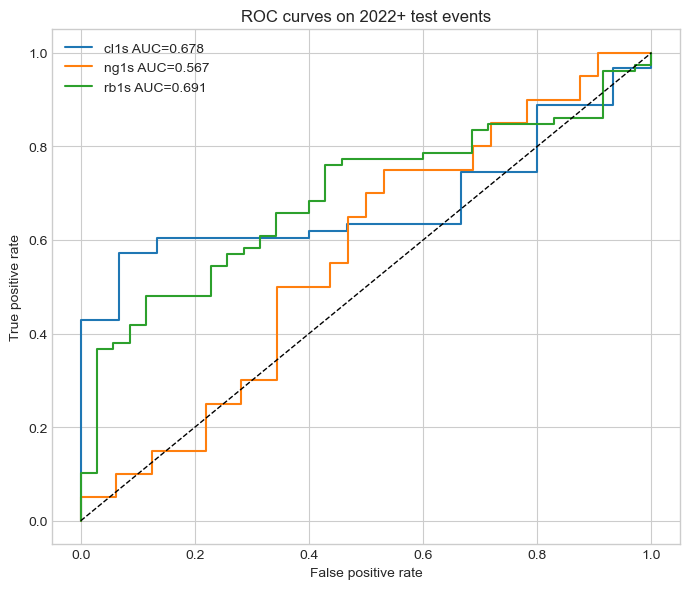

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
plotted = False
for instrument in instruments:
    group = detailed_predictions[detailed_predictions["instrument"] == instrument]
    y_true = group["y_true"].astype(int).to_numpy()
    y_proba = group["prediction"].astype(float).to_numpy()
    if len(np.unique(y_true)) < 2:
        print(f"Skipping ROC for {instrument}: only one class in test labels.")
        continue
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc_value = roc_auc_score(y_true, y_proba)
    ax.plot(fpr, tpr, label=f"{instrument} AUC={auc_value:.3f}")
    plotted = True

ax.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1)
ax.set_title("ROC curves on 2022+ test events")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
if plotted:
    ax.legend()
plt.tight_layout()
plt.show()

**Interpretation**

The ROC curves evaluate ranking quality across all thresholds, not just `0.5`. `rb1s` and `cl1s` both rank positives above negatives better than random, with `rb1s` slightly stronger in this test slice. `ng1s` is only modestly above random. `ho1s` is skipped because the test labels contain only one class, making ROC AUC mathematically undefined.

## Precision-Recall Curves

Skipping PR for ho1s: only one class in test labels.


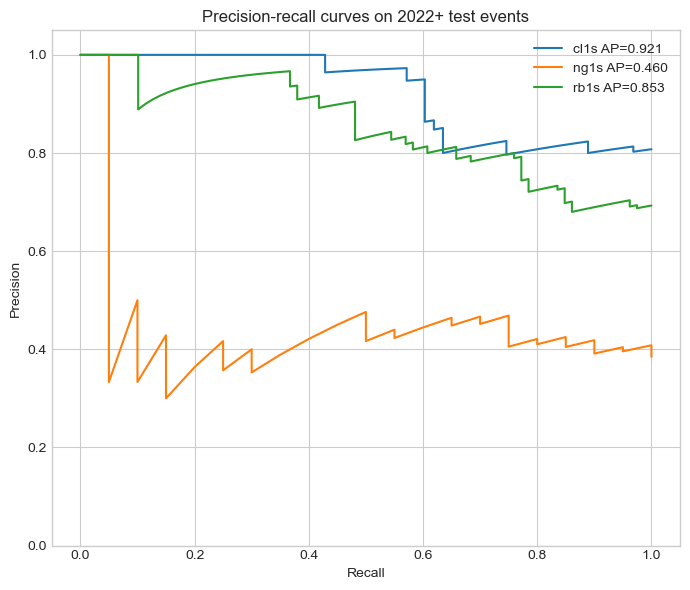

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
plotted = False
for instrument in instruments:
    group = detailed_predictions[detailed_predictions["instrument"] == instrument]
    y_true = group["y_true"].astype(int).to_numpy()
    y_proba = group["prediction"].astype(float).to_numpy()
    if len(np.unique(y_true)) < 2:
        print(f"Skipping PR for {instrument}: only one class in test labels.")
        continue
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    ap_value = average_precision_score(y_true, y_proba)
    ax.plot(recall, precision, label=f"{instrument} AP={ap_value:.3f}")
    plotted = True

ax.set_title("Precision-recall curves on 2022+ test events")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_ylim(0, 1.05)
if plotted:
    ax.legend()
plt.tight_layout()
plt.show()

**Interpretation**

Precision-recall is especially useful when the positive class dominates or class balance differs by instrument. `cl1s` has high average precision partly because positives are common in its test events. `rb1s` also has strong average precision and is more interesting because its class mix is less one-sided. `ng1s` again shows weaker separation, so raising or lowering its threshold would not solve the underlying ranking issue by itself.

## Calibration Check

Lower Brier score is better. The calibration plot compares average predicted probability with observed hit rate in probability bins.

Skipping calibration for ho1s: too few rows or only one class.


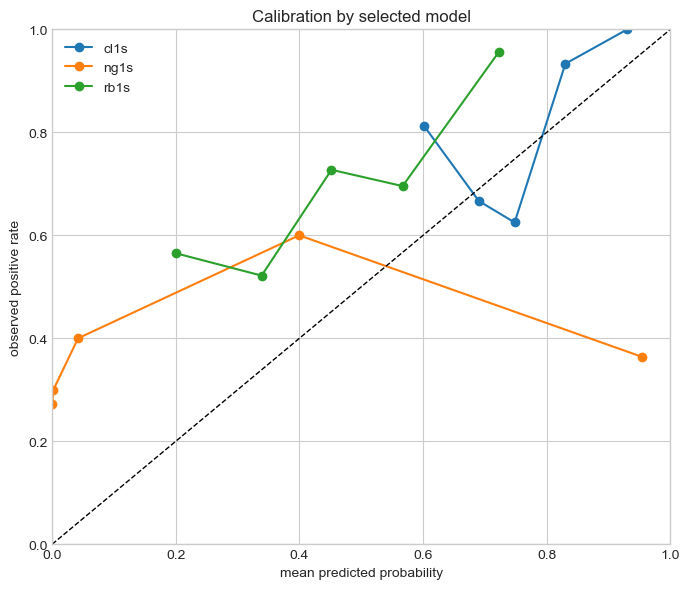

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
plotted = False
for instrument in instruments:
    group = detailed_predictions[detailed_predictions["instrument"] == instrument]
    y_true = group["y_true"].astype(int).to_numpy()
    y_proba = group["prediction"].astype(float).to_numpy()
    if len(np.unique(y_true)) < 2 or len(group) < 5:
        print(f"Skipping calibration for {instrument}: too few rows or only one class.")
        continue
    frac_pos, mean_pred = calibration_curve(y_true, y_proba, n_bins=min(5, len(group)), strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=instrument)
    plotted = True

ax.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1)
ax.set_title("Calibration by selected model")
ax.set_xlabel("mean predicted probability")
ax.set_ylabel("observed positive rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
if plotted:
    ax.legend()
plt.tight_layout()
plt.show()

**Interpretation**

The calibration plot checks whether predicted probabilities behave like real probabilities. Points close to the diagonal are better calibrated. With small per-instrument test samples, this should be read directionally rather than as a precise calibration study. Any severe deviation means the probabilities may still rank events reasonably but should be treated cautiously as absolute confidence values.

## Meta-Filter Return Diagnostics

This is a simple event-return view: `primary_return` takes every labelled primary signal, while `meta_return_0_5` only takes events where the model probability is at least `0.5`.

In [11]:
returns = detailed_predictions.copy()
returns["date"] = pd.to_datetime(returns["date"])
returns["primary_return"] = returns["signed_touch_return"].astype(float)
returns["meta_return_0_5"] = np.where(returns["prediction"] >= 0.5, returns["signed_touch_return"].astype(float), 0.0)

return_summary = (
    returns.groupby("instrument")
    .agg(
        n_events=("prediction", "size"),
        take_rate_0_5=("predicted_label", "mean"),
        mean_primary_return=("primary_return", "mean"),
        mean_meta_return_0_5=("meta_return_0_5", "mean"),
        total_primary_return=("primary_return", "sum"),
        total_meta_return_0_5=("meta_return_0_5", "sum"),
    )
    .reset_index()
)

return_path = OUTPUT_DIR / "test_set_return_diagnostics.csv"
return_summary.to_csv(return_path, index=False)
display(return_summary.round(4))
print(f"Saved return diagnostics: {return_path}")

,instrument,n_events,take_rate_0_5,mean_primary_return,mean_meta_return_0_5,total_primary_return,total_meta_return_0_5
0,cl1s,78,0.9872,0.0375,0.0364,2.9212,2.8409
1,ho1s,2,0.0000,-0.0750,0.0000,-0.1499,0.0000
2,ng1s,52,0.2692,-0.0203,0.0009,-1.0577,0.0450
3,rb1s,114,0.4386,0.0222,0.0169,2.5328,1.9300


Saved return diagnostics: /Users/faisal/Desktop/systematic-strategies-with-machine-learning-Cw/05_model_evaluation/outputs/test_set_return_diagnostics.csv


**Interpretation**

The return diagnostics compare taking every primary signal with applying the meta-model filter at `prediction >= 0.5`. This is not a full backtest with costs or sizing, but it tells whether the classifier is filtering events in the economically useful direction. A good meta-filter should improve average or cumulative event return while taking fewer trades; if it improves classification metrics but not event returns, the model may be accurate on labels that do not translate cleanly into PnL.

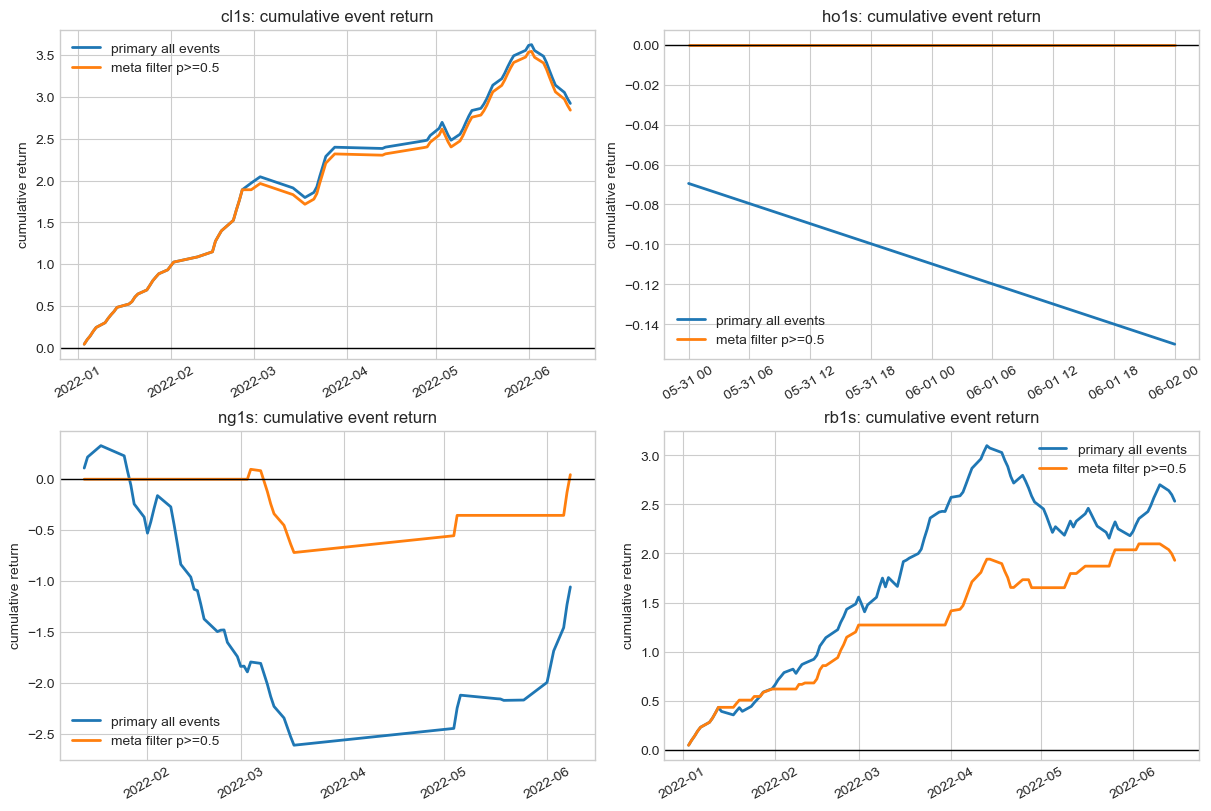

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes = axes.ravel()
for ax, instrument in zip(axes, instruments):
    group = returns[returns["instrument"] == instrument].sort_values("date")
    ax.plot(group["date"], group["primary_return"].cumsum(), label="primary all events", linewidth=2)
    ax.plot(group["date"], group["meta_return_0_5"].cumsum(), label="meta filter p>=0.5", linewidth=2)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"{instrument}: cumulative event return")
    ax.set_ylabel("cumulative return")
    ax.tick_params(axis="x", rotation=30)
    ax.legend()
plt.show()

**Interpretation**

The cumulative event-return plots show how the primary strategy and meta-filtered strategy evolve through the test window. Look for whether the meta-filter avoids drawdowns or preserves most upside while trading less. If the filtered line lags the primary line, the model may be rejecting profitable events despite reasonable classification metrics; if it smooths losses or lifts cumulative return, it is adding value as a trade filter.

## Final Deliverable Check

In [13]:
final_predictions = pd.read_csv(DELIVERABLE_PATH)
print(final_predictions.shape)
print(final_predictions.columns.tolist())
display(final_predictions.head())
display(final_predictions.groupby("instrument")["prediction"].agg(["count", "min", "mean", "max"]).round(4))

(246, 3)
['date', 'instrument', 'prediction']


,date,instrument,prediction
0,2022-01-03,cl1s,0.957689
1,2022-01-03,rb1s,0.630837
2,2022-01-04,cl1s,0.951089
3,2022-01-04,rb1s,0.582021
4,2022-01-05,cl1s,0.945801


,count,min,mean,max
instrument,,,,
cl1s,78,0.3870,0.7601,0.9577
ho1s,2,0.0883,0.1380,0.1878
ng1s,52,0.0000,0.2873,0.9996
rb1s,114,0.0886,0.4561,0.8586


**Interpretation**

The final deliverable remains intentionally minimal: one probability per test event with `date`, `instrument`, and `prediction`. The extra evaluation outputs stay in `05_model_evaluation/outputs/`, while `deliverables/final_predictions.csv` is the clean file to submit or pass downstream.